In [1]:
using DataFrames, CSV
using Plots

In [3]:
dir_source = "/workdir/tx84/Research/2024_LepChromosomes/00.assembly/Papilio_rutulusXglaucus"
cd(dir_source)

In [5]:
df = DataFrame(CSV.File("01.1.mito_cleaning/hifi_to_mito_padded.paf",header=false))

Row,Column1,Column2,Column3,Column4,Column5,Column6,Column7,Column8,Column9,Column10,Column11,Column12,Column13,Column14,Column15,Column16,Column17,Column18
,String,Int64,Int64,Int64,String1,String31,Int64,Int64,Int64,Int64,Int64,Int64,String7,String15,String15,String15,String15,String7
1,m84094_250320_053558_s3/254741505/ccs,19919,17976,18137,-,ptg000001l_rotated,30490,11135,11302,70,167,0,tp:A:P,cm:i:5,s1:i:68,s2:i:68,dv:f:0.0176,rl:i:0
2,m84094_250320_053558_s3/249565464/ccs,17377,5630,5793,+,ptg000001l_rotated,30490,26380,26547,87,169,0,tp:A:P,cm:i:6,s1:i:84,s2:i:84,dv:f:0.0150,rl:i:0
3,m84094_250320_053558_s3/249761643/ccs,19974,3529,3692,+,ptg000001l_rotated,30490,11135,11302,87,169,0,tp:A:P,cm:i:6,s1:i:84,s2:i:84,dv:f:0.0150,rl:i:0
4,m84094_250320_053558_s3/249434527/ccs,19541,12591,12874,-,ptg000001l_rotated,30490,18094,18403,152,309,0,tp:A:P,cm:i:10,s1:i:146,s2:i:146,dv:f:0.0095,rl:i:0
5,m84094_250320_053558_s3/253758664/ccs,20791,6732,6845,+,ptg000001l_rotated,30490,2485,2598,66,113,0,tp:A:P,cm:i:5,s1:i:66,s2:i:66,dv:f:0.0176,rl:i:0
6,m84094_250320_053558_s3/250877611/ccs,22282,11675,11850,-,ptg000001l_rotated,30490,14134,14311,107,177,0,tp:A:P,cm:i:8,s1:i:107,s2:i:107,dv:f:0.0117,rl:i:0
7,m84094_250320_053558_s3/255529676/ccs,19036,7237,7897,+,ptg000001l_rotated,30490,19506,20047,133,722,0,tp:A:P,cm:i:7,s1:i:88,s2:i:88,dv:f:0.0131,rl:i:0
8,m84094_250320_053558_s3/262738922/ccs,15359,5031,5621,+,ptg000001l_rotated,30490,4261,4754,114,654,0,tp:A:P,cm:i:6,s1:i:73,s2:i:73,dv:f:0.0150,rl:i:0
9,m84094_250320_053558_s3/254743391/ccs,23209,8911,8963,-,ptg000001l_rotated,30490,27854,27906,52,52,0,tp:A:P,cm:i:6,s1:i:52,s2:i:52,dv:f:0.0150,rl:i:0


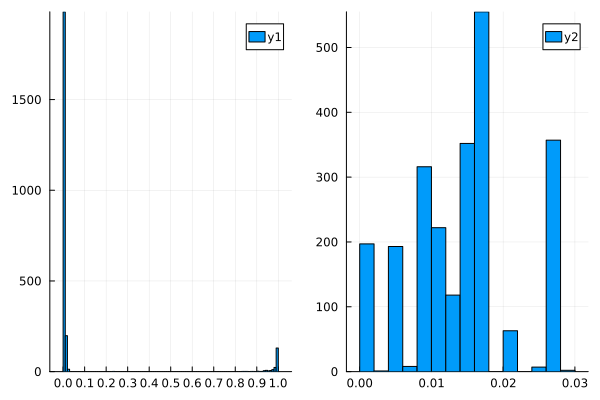

In [10]:
p = df[:,10] ./ df[:,2]
dv = parse.(Float64,getindex.(split.(df[:,17],":"),[3]))

fig = plot(layout=(1,2))
histogram!(fig,p,bins=0.0:0.01:1,xticks=0:0.1:1,subplot=1)
histogram!(fig,dv,subplot=2) 

In [14]:
idx = (p .>= 0.8) .& (dv .<= 0.03)
idx_rev = .! (idx)
discard_read_names = df[idx,1]
keep_read_names = df[idx_rev,1]

2196-element Vector{String}:
 "m84094_250320_053558_s3/254741505/ccs"
 "m84094_250320_053558_s3/249565464/ccs"
 "m84094_250320_053558_s3/249761643/ccs"
 "m84094_250320_053558_s3/249434527/ccs"
 "m84094_250320_053558_s3/253758664/ccs"
 "m84094_250320_053558_s3/250877611/ccs"
 "m84094_250320_053558_s3/255529676/ccs"
 "m84094_250320_053558_s3/262738922/ccs"
 "m84094_250320_053558_s3/254743391/ccs"
 "m84094_250320_053558_s3/261951307/ccs"
 "m84094_250320_053558_s3/260770876/ccs"
 "m84094_250320_053558_s3/256119038/ccs"
 "m84094_250320_053558_s3/246027107/ccs"
 ⋮
 "m84094_250320_053558_s3/244650219/ccs"
 "m84094_250320_053558_s3/239473051/ccs"
 "m84094_250320_053558_s3/247270993/ccs"
 "m84094_250320_053558_s3/265295461/ccs"
 "m84094_250320_053558_s3/220467070/ccs"
 "m84094_250320_053558_s3/228396395/ccs"
 "m84094_250320_053558_s3/214766269/ccs"
 "m84094_250320_053558_s3/241438078/ccs"
 "m84094_250320_053558_s3/244321398/ccs"
 "m84094_250320_053558_s3/219811057/ccs"
 "m84094_250320_053558_s3

In [15]:
dir_out = "$(dir_source)/01.1.mito_cleaning"

open(string(dir_out,"/reads_to_discard.txt"),"w") do file

    write(file, join(discard_read_names,"\n"))
    
end

7321